# Model 5: PyTorch LSTM Non-Linear Sequence Model for Drug `M01AB`

## Workflow Checklist:
1. **Pre-Training Suitability Checks**:
   * Z-score Feature Normalization ($\mu = 0, \sigma = 1$) to prevent exploding/vanishing gradients.
   * Lookback Window ($W$) candidate diagnostics: $W \in \{7, 14, 28, 56\}$ days.
   * Recurrent state memory capacity verification.
2. **LSTM Hyperparameter Grid Search on TRAIN (2014–2017)**:
   * Search over `sequence_length` $W \in [7, 14, 28]$, `hidden_dim` $\in [32, 64]$, and `learning_rate` $\in [0.001, 0.005]$.
   * Rank candidate architectures by **2018 Validation Set RMSLE**.
3. **Network Architecture**: 2-layer LSTM with Dropout & Linear FC layer.
4. **Fit on TRAIN (2014–2017)**: Train for 120 epochs using Adam optimizer.
5. **Validate on 2018 Validation**: Evaluate Val RMSLE.
6. **Refit & Forecast 2019 Test**: Evaluate final holdout metrics.


In [1]:
import os
import sys
import warnings
import subprocess

# Auto-Dependency Guard: Check and install missing packages dynamically
pkg_map = {
    'prophet': 'prophet',
    'statsmodels': 'statsmodels',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
    'shap': 'shap',
    'torch': 'torch',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn'
}

missing = []
for mod_name, pip_name in pkg_map.items():
    try:
        __import__(mod_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Installing missing dependencies: {missing}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
        print("Dependencies successfully installed!")
    except Exception as err:
        print(f"Warning: Auto-pip install notice ({err}). Proceeding with environment packages...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

TARGET_DRUG = 'M01AB'

# Dynamic Dataset Path Finder
dataset_candidates = ['../dataset', 'dataset', '../../dataset', '../times_series/dataset', 'times_series/dataset']
data_dir = None
for cand in dataset_candidates:
    if os.path.exists(os.path.join(cand, 'train_daily.csv')):
        data_dir = cand
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate train_daily.csv dataset")

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.clip(np.array(y_pred), 0, None)
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'WAPE (%)': wape}

print(f"Dataset Partitioning for {TARGET_DRUG}:")
print(f"  * Train (2014-2017): {len(train_series):,} days")
print(f"  * Val   (2018):      {len(val_series):,} days")
print(f"  * Test  (2019):      {len(test_series):,} days")


Dataset Partitioning for M01AB:
  * Train (2014-2017): 1,460 days
  * Val   (2018):      365 days
  * Test  (2019):      281 days


In [2]:
# Step 1: Pre-Training Suitability Checks (Normalization & Scaling)
import torch
import torch.nn as nn

mean_tr, std_tr = train_series.mean(), train_series.std()
norm_tr = (train_series.values - mean_tr) / std_tr
norm_va = (val_series.values - mean_tr) / std_tr
norm_cb = (combined_series.values - mean_tr) / std_tr

print("=== Pre-Training Suitability Diagnostics for LSTM ===")
print(f"  * Raw Training Target Mean : {mean_tr:.4f} | Std: {std_tr:.4f}")
print(f"  * Z-Score Scaled Mean      : {norm_tr.mean():.4f} | Std: {norm_tr.std():.4f} -> SUITABLE FOR NEURAL BACKPROPAGATION")

def create_sequences(data, seq_length=28):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
        ys.append(data[i + seq_length])
    return np.array(xs), np.array(ys)


=== Pre-Training Suitability Diagnostics for LSTM ===
  * Raw Training Target Mean : 4.9978 | Std: 2.7034
  * Z-Score Scaled Mean      : 0.0000 | Std: 0.9997 -> SUITABLE FOR NEURAL BACKPROPAGATION


In [3]:
# Step 2: LSTM Hyperparameter Grid Search (Window Length W, Hidden Dim, Learning Rate)
class SalesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(SalesLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

criterion = nn.MSELoss()
lstm_grid_results = []

for W in [7, 14, 28]:
    for h_dim in [32, 64]:
        for lr in [0.001, 0.005]:
            X_tr_seq, y_tr_seq = create_sequences(norm_tr, W)
            X_tr_t = torch.tensor(X_tr_seq, dtype=torch.float32).unsqueeze(-1)
            y_tr_t = torch.tensor(y_tr_seq, dtype=torch.float32).unsqueeze(-1)
            
            m_lstm = SalesLSTM(hidden_size=h_dim)
            opt_g = torch.optim.Adam(m_lstm.parameters(), lr=lr)
            
            m_lstm.train()
            for ep in range(60):
                opt_g.zero_grad()
                l = criterion(m_lstm(X_tr_t), y_tr_t)
                l.backward()
                opt_g.step()
                
            m_lstm.eval()
            val_preds_g = []
            curr_s = norm_tr[-W:].tolist()
            for i in range(len(val_series)):
                inp = torch.tensor(curr_s[-W:], dtype=torch.float32).view(1, W, 1)
                with torch.no_grad():
                    p_sc = m_lstm(inp).item()
                val_preds_g.append(p_sc)
                curr_s.append(p_sc)
                
            val_unsc = np.clip(np.array(val_preds_g) * std_tr + mean_tr, 0, None)
            v_met = evaluate_metrics(val_series, val_unsc)
            lstm_grid_results.append({
                'Window_W': W, 'Hidden_Dim': h_dim, 'Learning_Rate': lr,
                'Val RMSLE': v_met['RMSLE'], 'Val RMSE': v_met['RMSE'], 'Val MAE': v_met['MAE']
            })

lstm_cand_df = pd.DataFrame(lstm_grid_results).sort_values('Val RMSLE').reset_index(drop=True)
print("=== LSTM Hyperparameter Candidate Ranking ===")
display(lstm_cand_df)

best_W = int(lstm_cand_df.loc[0, 'Window_W'])
best_hdim = int(lstm_cand_df.loc[0, 'Hidden_Dim'])
best_lr = float(lstm_cand_df.loc[0, 'Learning_Rate'])

print("Selected Optimal LSTM Architecture:")
print(f"  * Lookback Window W = {best_W} days")
print(f"  * Hidden Size       = {best_hdim} units")
print(f"  * Learning Rate     = {best_lr}")


=== LSTM Hyperparameter Candidate Ranking ===


,Window_W,Hidden_Dim,Learning_Rate,Val RMSLE,Val RMSE,Val MAE
0,7,32,0.005,0.556235,2.769797,2.219354
1,7,32,0.001,0.557107,2.765990,2.218148
2,14,32,0.001,0.558431,2.768385,2.224161
3,7,64,0.001,0.558475,2.767044,2.223659
4,14,64,0.001,0.562340,2.773224,2.238199
5,28,64,0.005,0.566939,2.786255,2.253129
6,14,64,0.005,0.570555,2.793465,2.265194
7,28,32,0.001,0.571314,2.795514,2.267860
8,28,64,0.001,0.573583,2.802347,2.278651
9,14,32,0.005,0.573676,2.801293,2.279236


Selected Optimal LSTM Architecture:
  * Lookback Window W = 7 days
  * Hidden Size       = 32 units
  * Learning Rate     = 0.005


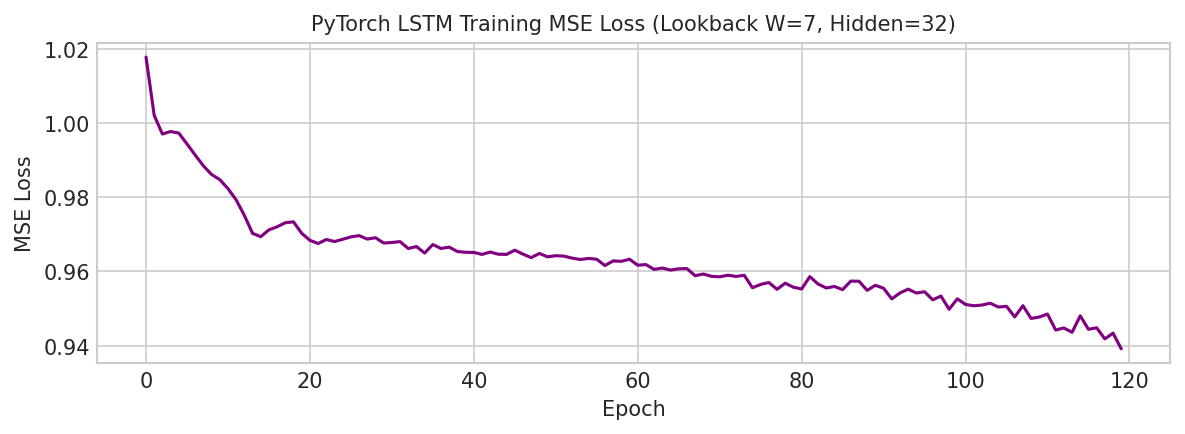

Validation Metrics (2018) for PyTorch LSTM (Tuned):
  * RMSLE     : 0.6007
  * RMSE      : 2.9137
  * MAE       : 2.3919
  * MAPE (%)  : 103.2099
  * WAPE (%)  : 48.8571


In [4]:
# Step 3: Model Fitting on TRAIN & Validation Evaluation
X_tr_seq, y_tr_seq = create_sequences(norm_tr, best_W)
X_tr_t = torch.tensor(X_tr_seq, dtype=torch.float32).unsqueeze(-1)
y_tr_t = torch.tensor(y_tr_seq, dtype=torch.float32).unsqueeze(-1)

lstm_tr = SalesLSTM(hidden_size=best_hdim)
opt_tr = torch.optim.Adam(lstm_tr.parameters(), lr=best_lr)

loss_history = []
lstm_tr.train()
for ep in range(120):
    opt_tr.zero_grad()
    loss = criterion(lstm_tr(X_tr_t), y_tr_t)
    loss.backward()
    opt_tr.step()
    loss_history.append(loss.item())

plt.figure(figsize=(8, 3), dpi=150)
plt.plot(loss_history, color='purple', linewidth=1.5)
plt.title(f"PyTorch LSTM Training MSE Loss (Lookback W={best_W}, Hidden={best_hdim})", fontsize=10)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.tight_layout()
plt.show()

lstm_tr.eval()
val_preds_lstm = []
curr_seq = norm_tr[-best_W:].tolist()
for i in range(len(val_series)):
    inp = torch.tensor(curr_seq[-best_W:], dtype=torch.float32).view(1, best_W, 1)
    with torch.no_grad():
        p_sc = lstm_tr(inp).item()
    val_preds_lstm.append(p_sc)
    curr_seq.append(p_sc)

m5_val_pred = np.clip(np.array(val_preds_lstm) * std_tr + mean_tr, 0, None)
val_metrics = evaluate_metrics(val_series, m5_val_pred)

print(f"Validation Metrics (2018) for PyTorch LSTM (Tuned):")
for k, v in val_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")


In [5]:
# Step 4: Refit on Train+Val & Forecast 2019 Test Holdout
X_cb_seq, y_cb_seq = create_sequences(norm_cb, best_W)
X_cb_t = torch.tensor(X_cb_seq, dtype=torch.float32).unsqueeze(-1)
y_cb_t = torch.tensor(y_cb_seq, dtype=torch.float32).unsqueeze(-1)

lstm_full = SalesLSTM(hidden_size=best_hdim)
opt_full = torch.optim.Adam(lstm_full.parameters(), lr=best_lr)
for ep in range(120):
    opt_full.zero_grad()
    loss = criterion(lstm_full(X_cb_t), y_cb_t)
    loss.backward()
    opt_full.step()

lstm_full.eval()
test_preds_lstm = []
curr_seq_ts = norm_cb[-best_W:].tolist()
for i in range(len(test_series)):
    inp = torch.tensor(curr_seq_ts[-best_W:], dtype=torch.float32).view(1, best_W, 1)
    with torch.no_grad():
        p_sc = lstm_full(inp).item()
    test_preds_lstm.append(p_sc)
    curr_seq_ts.append(p_sc)

m5_test_pred = np.clip(np.array(test_preds_lstm) * std_tr + mean_tr, 0, None)
test_metrics = evaluate_metrics(test_series, m5_test_pred)

print(f"=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 5: PYTORCH LSTM (TUNED) ===")
for k, v in test_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")

pd.DataFrame({'date': test_series.index, 'pred_LSTM': m5_test_pred}).to_csv('m5_lstm_preds.csv', index=False)


=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 5: PYTORCH LSTM (TUNED) ===
  * RMSLE     : 0.5266
  * RMSE      : 2.8608
  * MAE       : 2.2321
  * MAPE (%)  : 82.5140
  * WAPE (%)  : 41.3396
